# Dpi Setting

In [1]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100 # 300

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from package_sampling.sampling import up_tille, up_brewer, up_systematic, up_max_entropy
from package_sampling.utils import inclusion_probabilities


In [4]:
import os

print(os.getcwd())

/home/divar/projects/graphical-sampling/Simulations ipynb


In [5]:
import os
os.chdir('/home/divar/projects/graphical-sampling')

### Dependencies

### Python

In [6]:
# !pip install -q git+https://github.com/mehdimhb/geometric-sampling@dev
# !pip install git+https://github.com/mehdimhb/geometric-sampling@legacy-measure

In [7]:
!apt-get install -y r-base
#!pip install -q rpy2 tqdm


E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?


In [8]:
from rpy2.robjects.packages import importr

import numpy as np
from rpy2.robjects import numpy2ri, default_converter, globalenv
from rpy2.robjects.conversion import localconverter

/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "LD_LIBRARY_PATH" redefined by R and overriding existing variable. Current: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server", R: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server"
  warnings.warn(
/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_LIBS_SITE" redefined by R and overriding existing variable. Current: "/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library:/usr/lib/R/site-library:/usr/lib/R/library", R: "/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library:/usr/lib/R/site-library:/usr/lib/R/library:/usr/lib/R/library:/usr/lib/R/

In [9]:
%load_ext rpy2.ipython

### R

In [10]:
%%R

#library(spcosa)
#ibrary(spsurvey)
if(!require(WaveSampling)){
    install.packages("WaveSampling")
    library(WaveSampling)
}
if(!require(sampling)){
    install.packages("sampling")
    library(sampling)
}
if(!require(BalancedSampling)){
    install.packages("BalancedSampling")
    library(BalancedSampling)
}

Loading required package: WaveSampling
Loading required package: Matrix
Loading required package: sampling
Loading required package: BalancedSampling


### Imports

In [11]:
import matplotlib as mpl
import numpy as np
from rpy2.robjects import r, numpy2ri
import rpy2.robjects as ro
from matplotlib import pyplot as plt
from itertools import combinations
from collections import OrderedDict
import pandas as pd
import graphical_sampling as gs
from tqdm import tqdm
from tqdm.contrib import tenumerate
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

#numpy2ri.activate()

rng = gs.random.rng()

/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Functions

In [12]:
autumn_cmap = plt.get_cmap('autumn')
plasma_cmap = plt.get_cmap('plasma')

def get_autumn_colors(n_clusters):
    """Returns n_clusters colors from the autumn colormap."""
    colors = autumn_cmap(np.linspace(0.15, 0.95, n_clusters))
    return colors

def get_plasma_colors(n_clusters):
    """Returns n_clusters colors from the plasma colormap."""
    colors = plasma_cmap(np.linspace(0.15, 0.95, n_clusters))
    return colors

# Example usage:
n = 10  # Number of clusters
n_clusters = n
import matplotlib.pyplot as plt
import numpy as np

def lighten_color(color, amount=0.5):
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = np.array(mc.to_rgb(c))
    white = np.array([1, 1, 1])
    return tuple((1 - amount) * c + amount * white)

n_clusters = n
base_colors = plt.cm.plasma(np.linspace(0, 1, n_clusters))
light_colors = [lighten_color(col, 0.5) for col in base_colors]

autumn_colors = get_autumn_colors(n_clusters)
plasma_colors = get_plasma_colors(n_clusters)
plasma_colors = light_colors

In [13]:
import numpy as np
from scipy.spatial import ConvexHull, QhullError
from matplotlib.patches import Polygon

def plot_convex_hull(points, ax, color, alpha=0.33, edge_color="gray", line_width=0.6):
    """Plot a convex hull safely. Always returns (ax, hull or None)."""
    pts = np.asarray(points, dtype=float)
    if pts.shape[0] < 3:
        return ax, None
    try:
        # QJ adds tiny noise to handle collinear/duplicate points robustly
        hull = ConvexHull(pts, qhull_options='QJ')
        poly = Polygon(
            pts[hull.vertices],
            closed=True,
            facecolor=color,
            alpha=alpha,
            edgecolor=edge_color,
            linewidth=line_width,
            zorder=1
        )
        ax.add_patch(poly)
        return ax, hull
    except (QhullError, ValueError):
        # Fallback: skip hull if still degenerate
        return ax, None


# Simulations

### Three Simulated Population

In [81]:
import os
import numpy as np
import pandas as pd

BASE_DIR = "/home/divar/projects/graphical-sampling/populations"
pop_files = {
    "grid_eq":    "grid_eq_N=100.csv",
    "grid_uneq":  "grid_uneq_N=100.csv",
    "random_eq":  "random_eq_N=100.csv",
    "random_uneq":"random_uneq_N=100.csv",
    "clust_eq":   "clust_eq_N=100.csv",
    "clust_uneq": "clust_uneq_N=100.csv",
    "meuse_eq":   "meuse_eq_N=100.csv",
    "meuse_uneq": "meuse_uneq_N=100.csv",
    "swiss_eq":   "swiss_eq_fake_N=100.csv",
    "swiss_uneq": "swiss_uneq_fake_N=100.csv",
}

# sampler params
n = 4
n_zones = (2, 2)
zone_builder = "sweep"
units_order  = "spiral"
zones_order  = "spiral"
split_size   = 0.0001

populations   = {}
probabilities = {}
pop_objs      = {}
samplers      = {}

def _read_xyprob(csv_path: str):
    df = pd.read_csv(csv_path)
    xcol = "x" if "x" in df.columns else df.columns[0]
    ycol = "y" if "y" in df.columns else df.columns[1]
    pcol = "prob" if "prob" in df.columns else [c for c in df.columns if c.lower().startswith("prob")][0]
    coords = df[[xcol, ycol]].to_numpy(float)
    probs_raw = df[pcol].to_numpy(float)

    # --- crucial: scale first-order inclusion probabilities to sum to n ---
    total = probs_raw.sum()
    if total <= 0:
        raise ValueError(f"{os.path.basename(csv_path)} has non-positive total prob.")
    probs = probs_raw * (n / total)

    # tiny epsilon to avoid exact zeros if your code dislikes them (optional)
    # probs = np.clip(probs, 1e-12, None)

    # sanity check: warn if any > 1 (rare but possible with very skewed probs)
    if (probs > 1).any():
        print(f"Warning: some pi_i > 1 in {os.path.basename(csv_path)} after scaling.")

    return coords, probs

# read & build objects
for key, fname in pop_files.items():
    base = key.split("_")[0]
    csv_path = os.path.join(BASE_DIR, fname)

    coords, probs = _read_xyprob(csv_path)
    probabilities[key] = probs
    if base not in populations:
        populations[base] = coords

    pop = gs.sampling.Population(coords=coords, probs=probs)
    pop_objs[key] = pop

    hard = gs.sampling.KMeansSampler(
        population=pop,
        n=n,
        n_zones=n_zones,
        zone_builder=zone_builder,
        units_order=units_order,
        zones_order=zones_order,
        split_size=split_size,
    )
    samplers[key] = hard

print("Loaded keys:", sorted(pop_objs.keys()))
print("Sum of probs (should be n):", {k: round(v.sum(), 6) for k, v in probabilities.items()})


/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "LD_LIBRARY_PATH" redefined by R and overriding existing variable. Current: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server", R: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server"
  warnings.warn(
/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_LIBS_SITE" redefined by R and overriding existing variable. Current: "/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library:/usr/lib/R/site-library:/us

Loaded keys: ['clust_eq', 'clust_uneq', 'grid_eq', 'grid_uneq', 'meuse_eq', 'meuse_uneq', 'random_eq', 'random_uneq', 'swiss_eq', 'swiss_uneq']
Sum of probs (should be n): {'grid_eq': np.float64(4.0), 'grid_uneq': np.float64(4.0), 'random_eq': np.float64(4.0), 'random_uneq': np.float64(4.0), 'clust_eq': np.float64(4.0), 'clust_uneq': np.float64(4.0), 'meuse_eq': np.float64(4.0), 'meuse_uneq': np.float64(4.0), 'swiss_eq': np.float64(4.0), 'swiss_uneq': np.float64(4.0)}


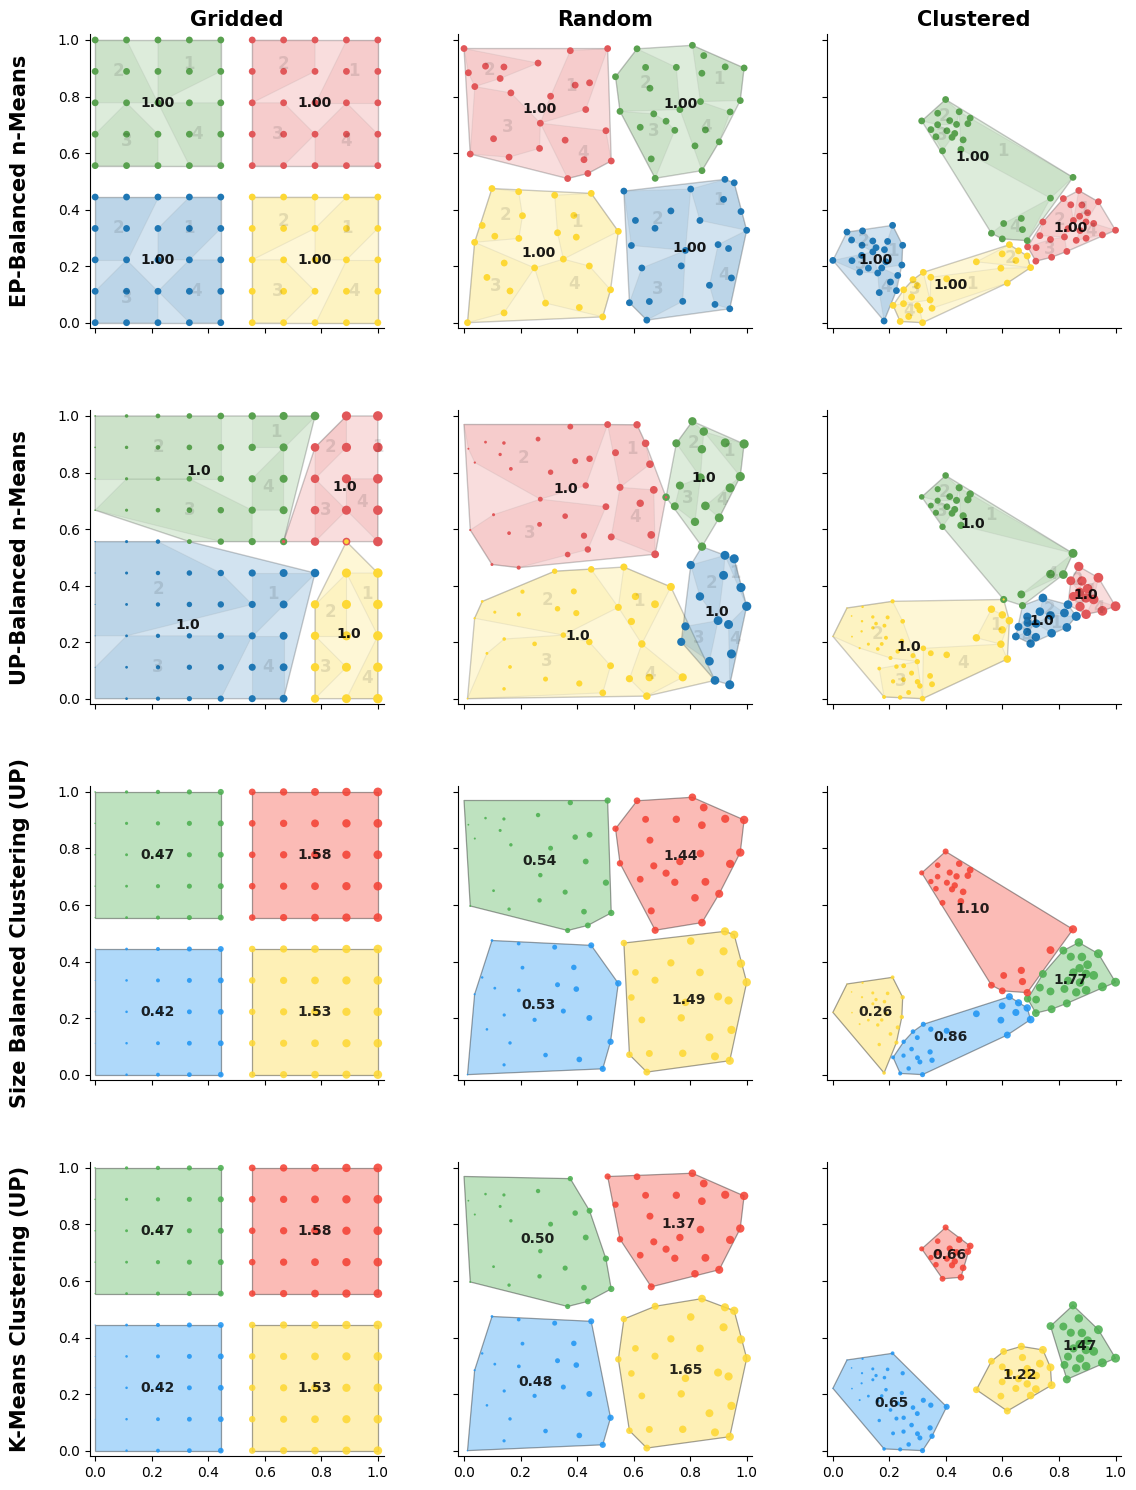

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from k_means_constrained import KMeansConstrained

# expects: pop_objs, samplers, (optional) backgrounds dict
# also expects your plot_convex_hull(points, ax, ...) function to be defined

# ---------- palette ----------
bardi_colors = [
    "#2196F3", "#FDD835", "#4CAF50", "#F44336",
    "#FF9800", "#9C27B0", "#E91E63", "#00BCD4",
    "#BDBDBD", "#FFD700"
]

def get_sorted_cluster_indices_by_lexico_centroids(centroids):
    order = np.lexsort((centroids[:, 0], centroids[:, 1]))
    label_to_color = np.zeros_like(order)
    for c, lab in enumerate(order): label_to_color[lab] = c
    return label_to_color, centroids[order]

def maybe_background(ax, model):
    base = model.split('_')[0]
    bg = globals().get('backgrounds', {}).get(base, None)
    if bg is not None:
        bg.plot(ax=ax, color="none", edgecolor="#4169E1", linewidth=2, alpha=0.8, zorder=0)

# ---------- layout ----------
n_clusters = n
models     = ['grid', 'random', 'clust']   # adjust if you want meuse/swiss
pop_titles = ['Gridded', 'Random', 'Clustered']
row_labels = [
    "EP-Balanced n-Means",
    "UP-Balanced n-Means",
    "Size Balanced Clustering (UP)",
    "K-Means Clustering (UP)",
]

fig, axes = plt.subplots(4, 3, figsize=(12, 15), sharex=True, sharey=True)

for col, model in enumerate(models):
    # ---------------- Row 1: GS (EP) ----------------
    ax = axes[0, col]
    maybe_background(ax, model)
    pop_eq  = pop_objs[f'{model}_eq']
    hard_eq = samplers[f'{model}_eq']
    gs.plot(pop_eq, hard_eq.clusters, ax=ax, size_scale=600)
    ax.set_title(pop_titles[col], fontsize=15, fontweight='bold')

    # (A) overlay sum of probs per GS cluster
    for cl in hard_eq.clusters:
        idx_share = cl.get_index_share(reduce=True)
        if idx_share.size == 0: continue
        idx    = idx_share[:, 0].astype(int)
        share  = idx_share[:, 1]
        psum   = float(np.sum(pop_eq.probs[idx] * share))
        center = pop_eq.coords[idx].mean(axis=0)
        ax.text(center[0], center[1], f"{psum:.2f}",
                color="black", fontsize=10, weight="bold",
                ha="center", va="center", alpha=0.9, zorder=5)

    # ---------------- Row 2: GS (UP) ----------------
    ax = axes[1, col]
    maybe_background(ax, model)
    pop_uneq  = pop_objs[f'{model}_uneq']
    hard_uneq = samplers[f'{model}_uneq']
    gs.plot(pop_uneq, hard_uneq.clusters, ax=ax, size_scale=600)

    # (A) overlay sum of probs per GS cluster
    for cl in hard_uneq.clusters:
        idx_share = cl.get_index_share(reduce=True)
        if idx_share.size == 0: continue
        idx    = idx_share[:, 0].astype(int)
        share  = idx_share[:, 1]
        psum   = float(np.sum(pop_uneq.probs[idx] * share))
        center = pop_uneq.coords[idx].mean(axis=0)
        ax.text(center[0], center[1], f"{psum:.1f}",
                color="black", fontsize=10, weight="bold",
                ha="center", va="center", alpha=0.9, zorder=5)

    # Prep once for rows 3–4
    X      = pop_uneq.coords
    probs  = pop_uneq.probs
    colors = bardi_colors[:n_clusters]

    # ---------------- Row 3: Size-balanced KMeans ----------------
    ax = axes[2, col]
    maybe_background(ax, model)

    kmeans_const = KMeansConstrained(
        n_clusters=n_clusters,
        size_min=int(X.shape[0] / n_clusters),
        size_max=int(np.ceil(X.shape[0] / n_clusters)),
        random_state=1
    ).fit(X)

    labels = kmeans_const.labels_
    centroids = np.array([X[labels == i].mean(axis=0) if np.any(labels == i) else np.array([np.nan, np.nan])
                          for i in range(n_clusters)])
    label_to_color, _ = get_sorted_cluster_indices_by_lexico_centroids(centroids)
    remapped = label_to_color[labels]

    for cidx in range(n_clusters):
        idx = (remapped == cidx)
        pts = X[idx]
        if pts.size == 0: continue
        # (B) ensure convex hull drawn for bottom rows
        ax, _ = plot_convex_hull(pts, ax, color=colors[cidx], alpha=0.36,
                                 edge_color='black', line_width=0.9)
        ax.scatter(pts[:, 0], pts[:, 1], color=colors[cidx],
                   s=probs[idx]*500, alpha=0.88, edgecolors="none", zorder=2)
        ax.text(pts[:,0].mean(), pts[:,1].mean(), f"{probs[idx].sum():.2f}",
                color="black", fontsize=10, weight="bold", alpha=0.85,
                ha="center", va="center", zorder=3)

    # ---------------- Row 4: Vanilla KMeans ----------------
    ax = axes[3, col]
    maybe_background(ax, model)

    km = KMeans(n_clusters=n_clusters, random_state=1).fit(X)
    labels = km.labels_
    centroids = np.array([X[labels == i].mean(axis=0) if np.any(labels == i) else np.array([np.nan, np.nan])
                          for i in range(n_clusters)])
    label_to_color, _ = get_sorted_cluster_indices_by_lexico_centroids(centroids)
    remapped = label_to_color[labels]

    for cidx in range(n_clusters):
        idx = (remapped == cidx)
        pts = X[idx]
        if pts.size == 0: continue
        ax, _ = plot_convex_hull(pts, ax, color=colors[cidx], alpha=0.36,
                                 edge_color='black', line_width=0.9)
        ax.scatter(pts[:, 0], pts[:, 1], color=colors[cidx],
                   s=probs[idx]*500, alpha=0.88, edgecolors="none", zorder=2)
        ax.text(pts[:,0].mean(), pts[:,1].mean(), f"{probs[idx].sum():.2f}",
                color="black", fontsize=10, weight="bold", alpha=0.85,
                ha="center", va="center", zorder=3)

# ---- formatting ----
for ax in axes.ravel():
    ax.set_aspect("equal")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel("")
    ax.set_ylabel("")

for r in range(4):
    axes[r,0].annotate(
        row_labels[r], xy=(0, 0.5),
        xytext=(-axes[r,0].yaxis.labelpad - 12, 0),
        xycoords=axes[r,0].yaxis.label, textcoords='offset points',
        size=15, ha='right', va='center', fontweight='bold', rotation=90
    )

plt.tight_layout()
plt.show()


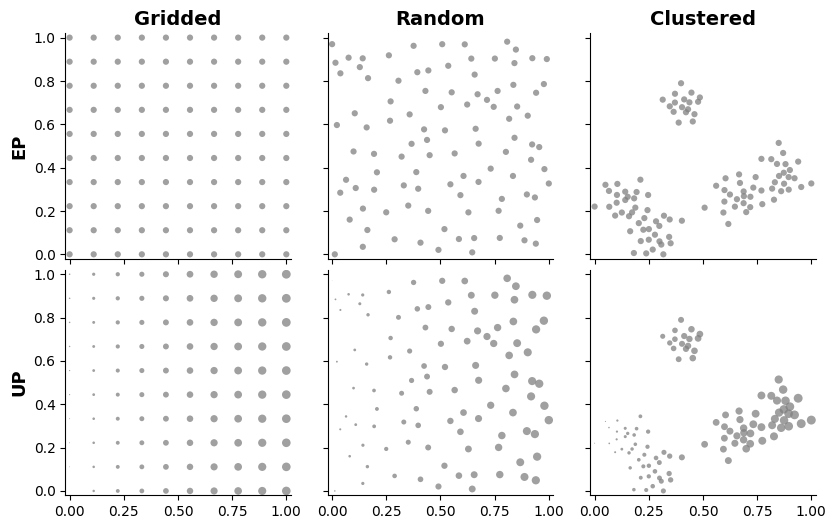

In [16]:
import matplotlib.pyplot as plt

pop_titles = ['Gridded', 'Random', 'Clustered']
row_labels = ["EP", "UP"]
models = ['grid', 'random', 'clust']

fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=True, sharey=True)

for col, model in enumerate(models):
    for row, prob_label in enumerate(['eq', 'uneq']):
        ax = axes[row, col]
        pops = pop_objs[f'{model}_{prob_label}']
        if hasattr(pops, 'coords'):
            X = pops.coords
            probs = pops.probs
        else:
            # pops is a DataFrame
            X = pops[['x', 'y']].values
            probs = pops['prob'].values

        ax.scatter(
            X[:, 0], X[:, 1],
            color='gray',
            s=probs * 500,      # <- Here: matches your original code
            alpha=0.75,
            edgecolors='none'
        )
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.02)
        ax.set_aspect("equal")
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if row == 0:
            ax.set_title(pop_titles[col], fontsize=14, weight='bold')
        if col == 0:
            ax.set_ylabel(row_labels[row], fontsize=13, weight='bold')
        else:
            ax.set_ylabel("")
plt.subplots_adjust(wspace=0.05, hspace=0.05)
#plt.tight_layout()
plt.show()

### Swiss

In [91]:



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.affinity import translate, scale

# --- paths ---
swiss_csv = '/home/divar/projects/graphical-sampling/swiss.csv'
swiss_shp = '/home/divar/Downloads/ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp'

# --- params ---
n = 16
n_zones      = (1, 1)
zone_builder = 'sweep'
units_order  = 'spiral'
zones_order  = 'spiral'


# ========= 1) Build Swiss populations & samplers =========
swiss_df   = pd.read_csv(swiss_csv)
coords     = swiss_df[['COORD_X', 'COORD_Y']].to_numpy(float)
N          = coords.shape[0]
area       = swiss_df['AREA'].clip( 1, 100)

# probabilities (rescale to sum to n for safety)
probs_eq   = (rng.equal_probabilities(n, N) if 'rng' in globals() else np.full(N, n/N))
probs_eq   = probs_eq * (n / probs_eq.sum())

probs_uneq = inclusion_probabilities(area, n)  # your function
probs_uneq = probs_uneq * (n / probs_uneq.sum())

# Population objects (NOTE: your Population class normalizes coords to unit [0,1])
pop_swiss_eq   = gs.sampling.Population(coords=coords, probs=probs_eq)
pop_swiss_uneq = gs.sampling.Population(coords=coords, probs=probs_uneq)

# Samplers
hard_swiss_eq = gs.sampling.KMeansSampler(
    population=pop_swiss_eq, n=n, n_zones=n_zones,
    zone_builder=zone_builder, units_order=units_order,
    zones_order=zones_order, split_size=0.001
)
hard_swiss_uneq = gs.sampling.KMeansSampler(
    population=pop_swiss_uneq, n=n, n_zones=n_zones,
    zone_builder=zone_builder, units_order=units_order,
    zones_order=zones_order, split_size=0.001
)

# (Optional) stash in your dicts for later reuse
pop_objs = {
    'swiss_eq':   pop_swiss_eq,
    'swiss_uneq': pop_swiss_uneq,
}
samplers = {
    'swiss_eq':   hard_swiss_eq,
    'swiss_uneq': hard_swiss_uneq,
}



/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "LD_LIBRARY_PATH" redefined by R and overriding existing variable. Current: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server", R: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server"
  warnings.warn(
/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_LIBS_SITE" redefined by R and overriding existing variable. Current: "/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library:/usr/lib/R/site-library:/us

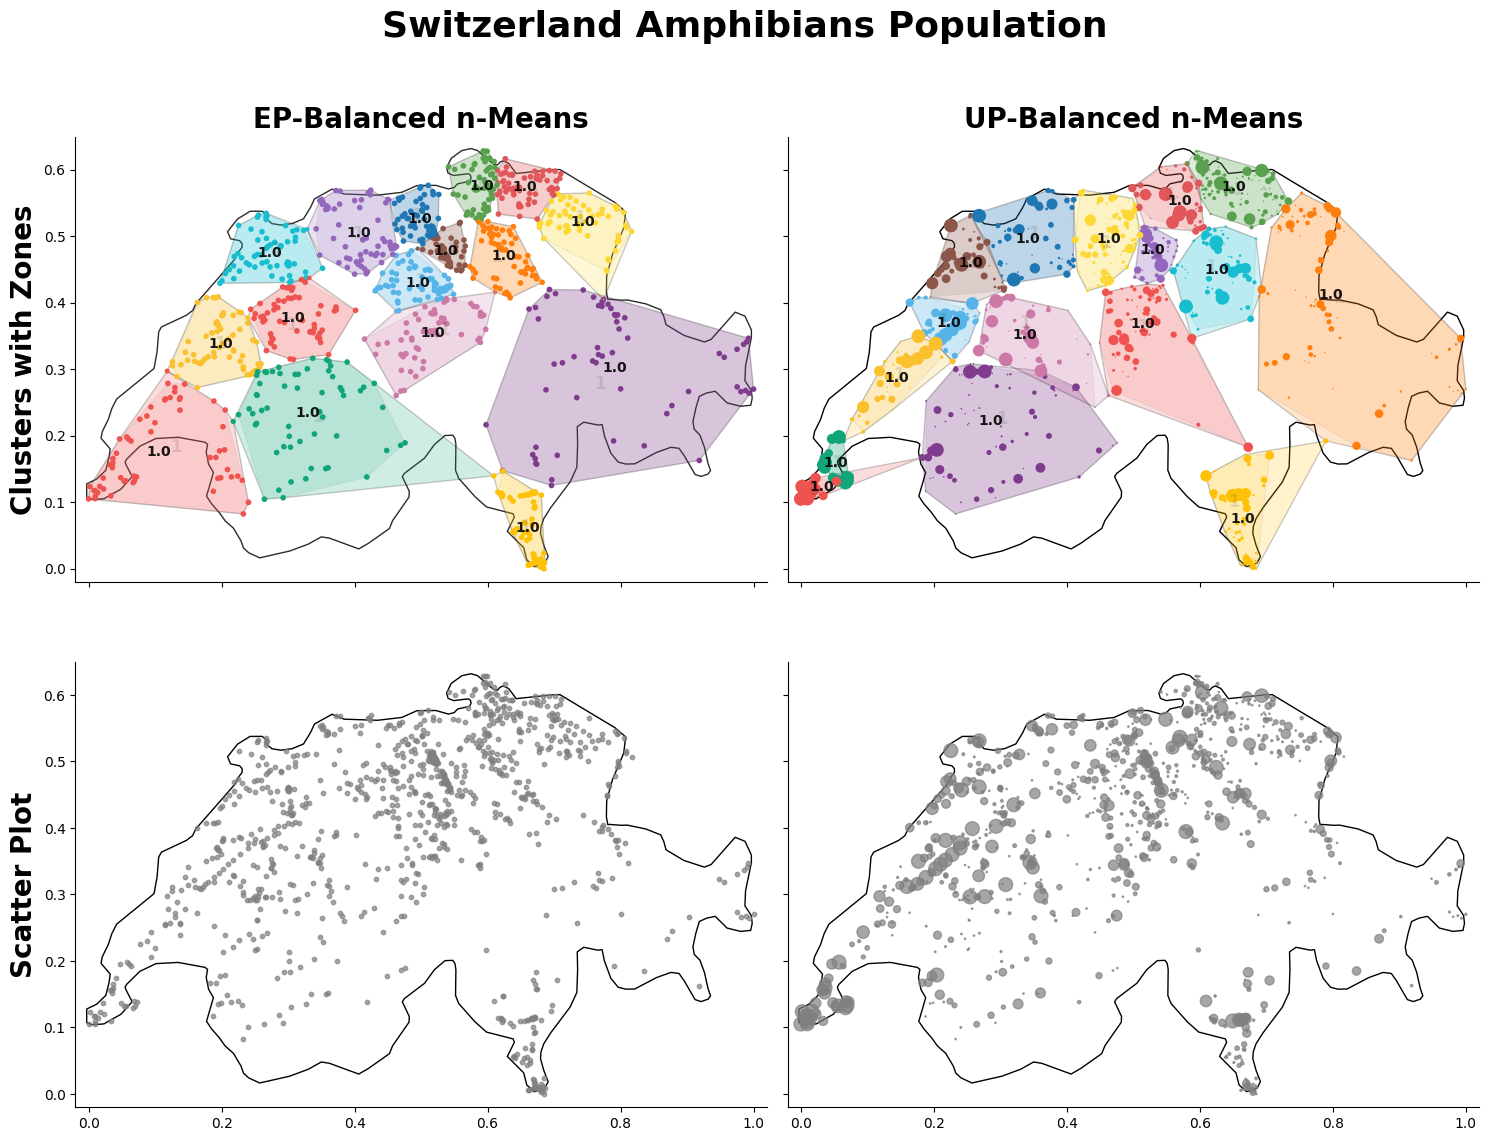

In [98]:
# ========= 2) Swiss shapefile → same unit frame as Population =========
world     = gpd.read_file(swiss_shp)
swiss_map = world[world['ADMIN'] == 'Switzerland'].to_crs(epsg=2056)
size_scale = 1000

mins       = coords.min(axis=0)
scale_val  = float(np.ptp(coords, axis=0).max())
swiss_unit = swiss_map.copy()
if scale_val > 0:
    swiss_unit['geometry'] = swiss_unit.geometry.apply(
        lambda g: scale(
            translate(g, xoff=-mins[0], yoff=-mins[1]),
            xfact=1.0/scale_val, yfact=1.0/scale_val, origin=(0, 0)
        )
    )

def add_cluster_sums(ax, pop, clusters, fmt="{:.2f}"):
    """Write sum of probabilities per cluster at the cluster centroid."""
    for cl in clusters:
        idx_share = cl.get_index_share(reduce=True)
        if idx_share.size == 0:
            continue
        idx   = idx_share[:, 0].astype(int)
        share = idx_share[:, 1]
        pts   = pop.coords[idx]
        probs = pop.probs[idx] * share
        center = pts.mean(axis=0)
        ax.text(center[0], center[1], f"{probs.sum():.1f}",
                ha="center", va="center", fontsize=10, weight="bold",
                color="black", alpha=0.9, zorder=5)

col_labels = ["EP-Balanced n-Means", "UP-Balanced n-Means"]
fig, axes = plt.subplots(2, 2, figsize=(15, 12), sharex=True, sharey=True)

# --- BOTTOM ROW: scatters ---
for col, key in enumerate(['swiss_eq', 'swiss_uneq']):
    ax = axes[1, col]
    swiss_unit.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.0, zorder=0)
    P = pop_objs[key]
    if key == 'swiss_eq':
        ax.scatter(P.coords[:, 0], P.coords[:, 1], c="gray", s=10, alpha=0.7, zorder=2)
    else:
        s = np.clip(P.probs * 1000.0, 1, 100)
        ax.scatter(P.coords[:, 0], P.coords[:, 1], c="gray", s=s, alpha=0.7, zorder=2)

# --- TOP ROW: GS clusters/hulls over borders + sums ---
swiss_unit.plot(ax=axes[0, 0], facecolor="none", edgecolor="#2B2B2B", linewidth=1.0, zorder=0)
gs.plot(pop_objs['swiss_eq'], samplers['swiss_eq'].clusters, ax=axes[0, 0], size_scale=size_scale)
add_cluster_sums(axes[0, 0], pop_objs['swiss_eq'], samplers['swiss_eq'].clusters)
axes[0, 0].set_title(col_labels[0], fontsize=20, fontweight='bold')

swiss_unit.plot(ax=axes[0, 1], facecolor="none", edgecolor="black", linewidth=1.0, zorder=0)
gs.plot(pop_objs['swiss_uneq'], samplers['swiss_uneq'].clusters, ax=axes[0, 1], size_scale=size_scale)
add_cluster_sums(axes[0, 1], pop_objs['swiss_uneq'], samplers['swiss_uneq'].clusters)
axes[0, 1].set_title(col_labels[1], fontsize=20, fontweight='bold')

# --- Cosmetics ---
for ax in axes.flatten():
    ax.set_aspect("equal")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 0.65)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[1, 0].set_ylabel("Scatter Plot", fontsize=20, fontweight='bold')
axes[0, 0].set_ylabel("Clusters with Zones", fontsize=20, fontweight='bold')

plt.tight_layout(rect=[0, 0.01, 1, 0.96])
plt.suptitle("Switzerland Amphibians Population", fontsize=26, fontweight='bold', y=0.995)
plt.show()


### 2024 paper

In [16]:
# === Cell A: build Population + Sampler objects for the two CSVs ===
import os
import numpy as np
import pandas as pd
import graphical_sampling as gs  # <- your package (adjust if your import name differs)

# ---- paths (adjust if needed) ----
BASE_DIR = "/home/divar/projects/graphical-sampling/populations"
FILES = {
    "agg": "AggregatedPop1027_2d.csv",
    "reg": "RegularPop1000_2d.csv",
}

# ---- sampler params ----
n             = 20                 # target sample size (=> 20 clusters)
n_zones       = (2, 2)             # zones per cluster (same as you’ve been using)
zone_builder  = "sweep"
units_order   = "spiral"
zones_order   = "spiral"
split_size    = 0.01

# ---- holders ----
pop_objs = {}     # key -> gs.sampling.Population
samplers = {}     # key -> gs.sampling.KMeansSampler

def read_xy(csv_path: str) -> np.ndarray:
    """Read coords from CSV; tolerate different column names. Returns (N,2) float array."""
    df = pd.read_csv(csv_path)
    # prefer 'x','y' if present; else take first two columns
    if {"x", "y"}.issubset(df.columns):
        XY = df[["x", "y"]].to_numpy(float)
    else:
        XY = df.iloc[:, :2].to_numpy(float)
    return XY

for key, fname in FILES.items():
    csv_path = os.path.join(BASE_DIR, fname)
    coords = read_xy(csv_path)
    N = coords.shape[0]

    # equal inclusion probabilities that sum to n
    probs = np.full(N, n / N, dtype=float)

    # build Population (note: your Population normalizes coords to ~[0,1])
    P = gs.sampling.Population(coords=coords, probs=probs)
    pop_objs[key] = P

    # build sampler (Balanced n-Means), which creates clusters and zones
    hard = gs.sampling.KMeansSampler(
        population=P,
        n=n,
        n_zones=n_zones,
        zone_builder=zone_builder,
        units_order=units_order,
        zones_order=zones_order,
        split_size=split_size,
    )
    samplers[key] = hard

print("Built:", list(pop_objs.keys()))


/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "LD_LIBRARY_PATH" redefined by R and overriding existing variable. Current: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server", R: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server"
  warnings.warn(
/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_LIBS_SITE" redefined by R and overriding existing variable. Current: "/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library:/usr/lib/R/site-library:/us

Built: ['agg', 'reg']


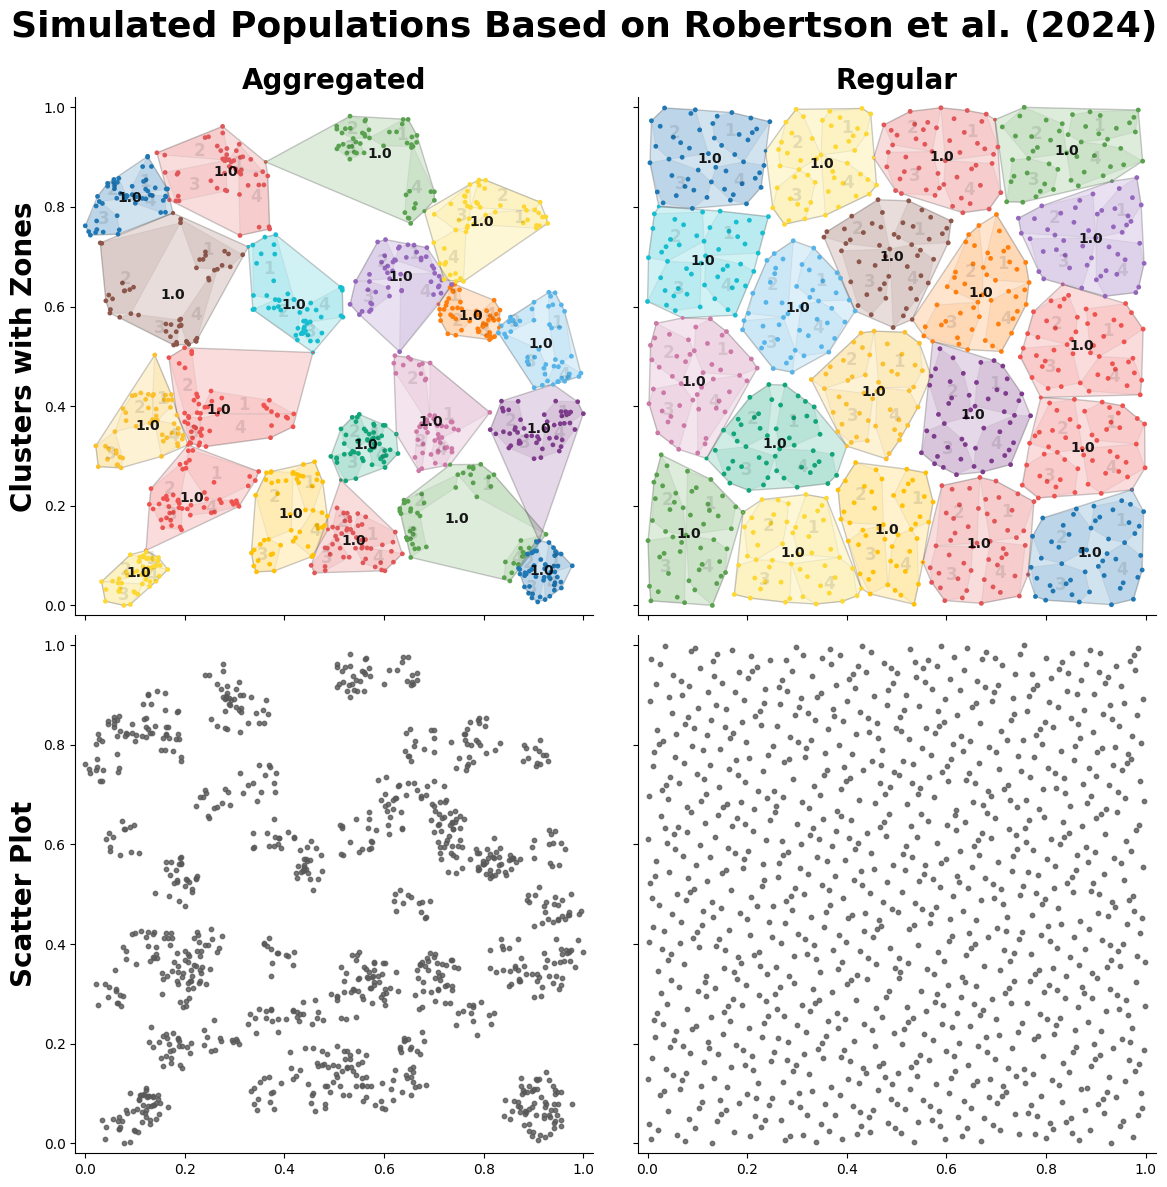

In [29]:
# === Cell B: plot 2×2 (top: clusters with zones + prob sums, bottom: scatters) ===
import matplotlib.pyplot as plt
import numpy as np

def annotate_cluster_sums(ax, P, clusters):
    """Write sum of probabilities (one decimal) at each cluster's centroid."""
    for cl in clusters:
        idx_share = cl.get_index_share(reduce=True)
        if idx_share.size == 0:
            continue
        unit_idx = idx_share[:, 0].astype(int)
        shares   = idx_share[:, 1]
        coords   = P.coords[unit_idx]
        probs    = P.probs[unit_idx] * shares
        total    = probs.sum()
        center   = coords.mean(axis=0)       # simple centroid is fine for labeling
        ax.text(center[0], center[1], f"{total:.1f}",
                ha="center", va="center", fontsize=10,
                weight="bold", color="black", alpha=0.9, zorder=5)

# figure
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharex=True, sharey=True)
titles = {"agg": "Aggregated", "reg": "Regular"}
size_scale = 600  # controls gs.plot marker sizes

# ---- top row: clusters + zones via gs.plot + prob-sum labels ----
ax = axes[0, 0]
gs.plot(pop_objs["agg"], samplers["agg"].clusters, ax=ax, size_scale=size_scale)
annotate_cluster_sums(ax, pop_objs["agg"], samplers["agg"].clusters)
ax.set_title(titles["agg"], fontsize=20, fontweight="bold")

ax = axes[0, 1]
gs.plot(pop_objs["reg"], samplers["reg"].clusters, ax=ax, size_scale=size_scale)
annotate_cluster_sums(ax, pop_objs["reg"], samplers["reg"].clusters)
ax.set_title(titles["reg"], fontsize=20, fontweight="bold")

# ---- bottom row: simple scatters (no titles) ----
for j, key in enumerate(["agg", "reg"]):
    ax = axes[1, j]
    P = pop_objs[key]
    ax.scatter(P.coords[:, 0], P.coords[:, 1], s=10, c="0.35", alpha=0.8, zorder=2)

# cosmetics
for ax in axes.ravel():
    ax.set_aspect("equal")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[1, 0].set_ylabel("Scatter Plot", fontsize=20, fontweight="bold")
axes[0, 0].set_ylabel("Clusters with Zones", fontsize=20, fontweight="bold")
plt.tight_layout(rect=[0, 0.01, 1, 0.96])
plt.suptitle("Simulated Populations Based on Robertson et al. (2024)", fontsize=26, fontweight='bold', y=0.995)
plt.show()


### Meuse

In [30]:
import numpy as np
import pandas as pd

# --- SEEDING for reproducibility ---
np.random.seed(42)

# --- PARAMS ---
n = 15  # Target sample size
meuse_csv = '/home/divar/projects/graphical-sampling/meuse.csv'

# --- 1) Load MEUSE and make probabilities ---
meuse_df = pd.read_csv(meuse_csv)
coords_meuse = meuse_df[['x', 'y']].to_numpy()
N_meuse = coords_meuse.shape[0]
area = meuse_df['copper'].clip(1, 150)

# Assumes you have these in scope:
#   rng.equal_probabilities(n, N)
#   inclusion_probabilities(area, n)
probs_meuse_eq   = rng.equal_probabilities(n, N_meuse)
probs_meuse_uneq = inclusion_probabilities(area, n)

# --- 2) Build Population objects (so we keep coords & probs together) ---
pop_eq = gs.sampling.Population(coords=coords_meuse, probs=probs_meuse_eq)
pop_uneq = gs.sampling.Population(coords=coords_meuse, probs=probs_meuse_uneq)

# --- 3) Sampler params ---
units_order = 'spiral'
zones_order = 'spiral'
zone_builder = 'sweep'
n_zones = (1, 1)

# --- 4) Build samplers (KEEP REFERENCES!) ---
hard_eq = gs.sampling.KMeansSampler(
    population=pop_eq,
    n=n,
    n_zones=n_zones,
    zone_builder=zone_builder,
    units_order=units_order,
    zones_order=zones_order,
    split_size=0.1
)

hard_uneq = gs.sampling.KMeansSampler(
    population=pop_uneq,
    n=n,
    n_zones=n_zones,
    zone_builder=zone_builder,
    units_order=units_order,
    zones_order=zones_order,
    split_size=0.1
)

# If your implementation requires it, uncomment:
# hard_eq.build(); hard_uneq.build()

# --- 5) (Optional) keep populations in a dict if you like that pattern ---
pop_objs = {
    'meuse_eq':   hard_eq.population,   # Population object
    'meuse_uneq': hard_uneq.population, # Population object
}

# IMPORTANT: do NOT overwrite hard_eq / hard_uneq with populations.
# Leave them pointing to the sampler objects, e.g.:
# hard_eq is the sampler for equal-prob; hard_uneq is the sampler for unequal-prob.


/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "LD_LIBRARY_PATH" redefined by R and overriding existing variable. Current: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server", R: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server"
  warnings.warn(
/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_LIBS_SITE" redefined by R and overriding existing variable. Current: "/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library:/usr/lib/R/site-library:/us

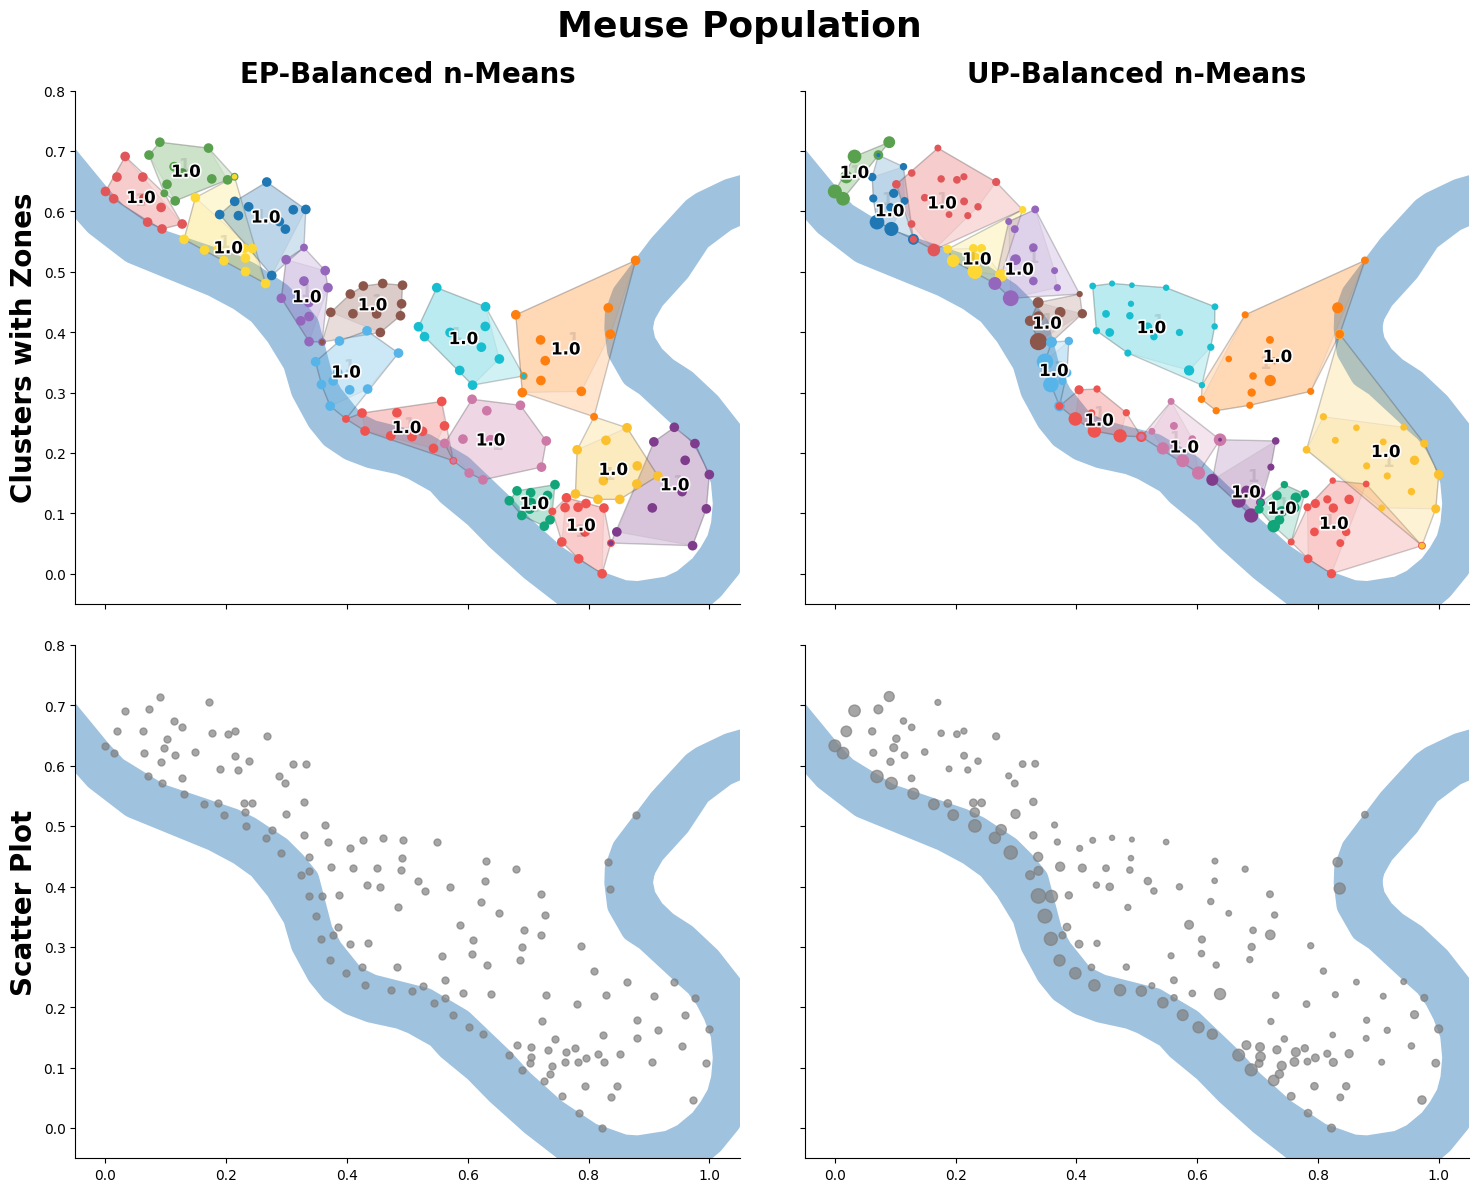

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.affinity import translate, scale, rotate
from matplotlib import patheffects as pe

# --- River -> normalize to unit space like Population, then rotate 90° left ---
river = gpd.read_file("/home/divar/projects/graphical-sampling/meuse_river.shp").to_crs(epsg=28992)

XY    = meuse_df[['x','y']].to_numpy(float)
mins  = XY.min(axis=0)
span  = np.ptp(XY, axis=0)
scale_val = float(span.max())

river_unit = river.copy()
if scale_val > 0:
    river_unit["geometry"] = river_unit.geometry.apply(
        lambda g: scale(translate(g, xoff=-mins[0], yoff=-mins[1]),
                        xfact=1.0/scale_val, yfact=1.0/scale_val, origin=(0, 0))
    )

# rotate left 90° around (0,0); shift +1 in x to keep it in [0,1]
river_rot = river_unit.copy()
river_rot["geometry"] = river_rot.geometry.apply(
    lambda g: translate(rotate(g, 90, origin=(0, 0)), xoff=1.0, yoff=0.0)
)

# rotate points in unit space: x' = 1 - y, y' = x
def rot_left_unit(coords):
    return np.column_stack([1.0 - coords[:, 1], coords[:, 0]])

# rotated populations just for plotting (clusters still refer to indices)
pop_eq_rot   = gs.sampling.Population(coords=rot_left_unit(pop_eq.coords),   probs=pop_eq.probs,   ids=pop_eq.ids)
pop_uneq_rot = gs.sampling.Population(coords=rot_left_unit(pop_uneq.coords), probs=pop_uneq.probs, ids=pop_uneq.ids)

# --- Labels and figure, styled like your Switzerland code ---
col_labels = ["EP-Balanced n-Means", "UP-Balanced n-Means"]

fig, axes = plt.subplots(2, 2, figsize=(15, 12), sharex=True, sharey=True)

for col, (pops, hard, key) in enumerate([(pop_eq_rot, hard_eq, 'meuse_eq'),
                                         (pop_uneq_rot, hard_uneq, 'meuse_uneq')]):

    # ----------- BOTTOM ROW: scatter over river -----------
    ax = axes[1, col]
    river_rot.plot(ax=ax, color="#87b3d8", linewidth=20, alpha=0.8, zorder=0)
    coords = pops.coords
    probs  = pops.probs

    if key == 'meuse_eq':
        ax.scatter(coords[:, 0], coords[:, 1], c="gray", s=25, alpha=0.7, zorder=2)
    else:
        s = probs * 350.0
        ax.scatter(coords[:, 0], coords[:, 1], c="gray", s=s, alpha=0.7, zorder=2)

    # ----------- TOP ROW: clusters/hulls over river -----------
    ax = axes[0, col]
    river_rot.plot(ax=ax, color="#87b3d8", linewidth=20, alpha=0.8, zorder=0)
    gs.plot(pops, hard.clusters, ax=ax, size_scale=500)  # draws hulls/zones/points
    ax.set_title(col_labels[col], fontsize=20, fontweight='bold')
    ax.set_aspect("equal")

    # ---- NEW: probability-sum label per cluster (1 decimal) ----
    for cl in hard.clusters:
        idx_share = cl.get_index_share(reduce=True)
        if idx_share.size == 0:
            continue
        idx   = idx_share[:, 0].astype(int)
        share = idx_share[:, 1]
        cxy   = pops.coords[idx]
        w     = pops.probs[idx] * share
        wsum  = float(w.sum())
        if cxy.size == 0:
            continue
        # weighted centroid for label placement
        center = (cxy * w[:, None]).sum(axis=0) / wsum if wsum > 0 else cxy.mean(axis=0)
        txt = ax.text(center[0], center[1], f"{wsum:.1f}",
                      ha='center', va='center', fontsize=12, fontweight='bold',
                      color='black', zorder=6)
        # white stroke for legibility
        txt.set_path_effects([pe.withStroke(linewidth=2.5, foreground='white', alpha=0.9)])

# Only show left and bottom spines (like Swiss)
for ax in axes.flatten():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel("")
    ax.set_ylabel("")

# row labels
axes[0, 0].set_ylabel("Clusters with Zones", fontsize=20, fontweight='bold')
axes[1, 0].set_ylabel("Scatter Plot", fontsize=20, fontweight='bold')

# Common limits in rotated unit space
for ax in axes.flatten():
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 0.80)

plt.tight_layout(rect=[0, 0.01, 1, 0.96])
plt.subplots_adjust(wspace=0.08, hspace=0.08)
plt.suptitle("Meuse Population", fontsize=26, fontweight='bold', y=0.995)
plt.show()


### Two Amir Examples

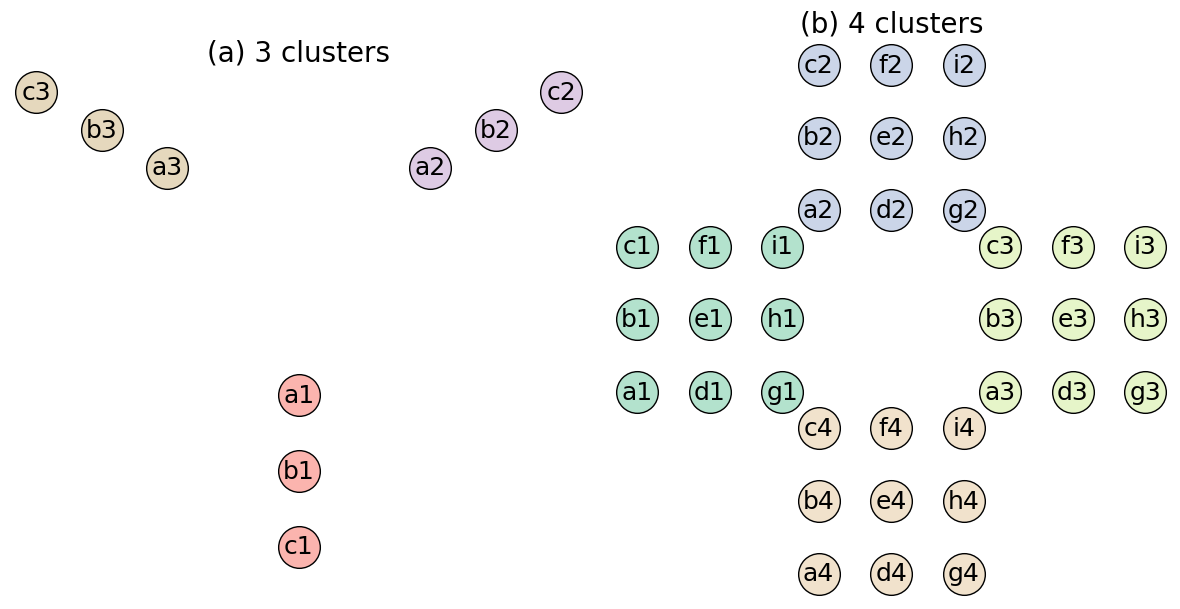

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def rotate_point(p, t, cost=None, sint=None):
    if cost is None or sint is None:
        cost, sint = np.cos(t), np.sin(t)
    return np.array([p[0]*cost - p[1]*sint, p[0]*sint + p[1]*cost])

def rotate_matrix(matrix, t, cost=None, sint=None):
    if cost is None or sint is None:
        cost, sint = np.cos(t), np.sin(t)
    return np.apply_along_axis(rotate_point, 1, matrix, t, cost, sint)

# ---------- Left subplot: 3 clusters ----------
template = np.array([[0.0, -2.0],
                     [0.0, -3.0],
                     [0.0, -4.0]])
angles = np.arange(0, 3) * (2*np.pi/3)
pop_left = np.vstack([rotate_matrix(template, angle) for angle in angles])
labels_left = ["a1","b1","c1","a2","b2","c2","a3","b3","c3"]

# group by digit (1,2,3) instead of letter
digits_left = np.array([lab[-1] for lab in labels_left])
unique_digits = sorted(set(digits_left))
colors_left = {d: plt.cm.Pastel1(i/len(unique_digits)) for i,d in enumerate(unique_digits)}

# ---------- Right subplot: 4 clusters ----------
grid = np.array([[i,j] for i in range(3) for j in range(3)], float)
left  = grid + [1,3.5]
right = grid + [6,3.5]
up    = grid + [3.5,6]
down  = grid + [3.5,1]
coords_right = np.vstack([left,right,up,down])

letters_abc = [chr(ord('a')+i) for i in range(9)]
labels_right = [f"{l}1" for l in letters_abc] + \
               [f"{l}3" for l in letters_abc] + \
               [f"{l}2" for l in letters_abc] + \
               [f"{l}4" for l in letters_abc]

digits_right = np.array([lab[-1] for lab in labels_right])
unique_digits = sorted(set(digits_right))
colors_right = {d: plt.cm.Pastel2(i/len(unique_digits)) for i,d in enumerate(unique_digits)}

# ---------- Plot ----------
fig, axes = plt.subplots(1,2,figsize=(12,6))
for ax in axes:
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)  # remove frames

# Left plot
ax = axes[0]
for (x,y), lab, d in zip(pop_left, labels_left, digits_left):
    ax.plot(x, y, 'o', markersize=30,
            markerfacecolor=colors_left[d],
            markeredgecolor='black')
    ax.text(x, y, lab, ha='center', va='center', fontsize=18)
ax.set_title("(a) 3 clusters", fontsize=20)

# Right plot
ax = axes[1]
for (x,y), lab, d in zip(coords_right, labels_right, digits_right):
    ax.plot(x, y, 'o', markersize=30,
            markerfacecolor=colors_right[d],
            markeredgecolor='black')
    ax.text(x, y, lab, ha='center', va='center', fontsize=18)
ax.set_title("(b) 4 clusters", fontsize=20)

plt.tight_layout()
plt.show()
